In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def load_exam(data_path=r"C:\Users\nooth\Downloads"):
    csv_path = os.path.join(data_path,"WA_Fn-UseC_-HR-Employee-Attrition")
    return pd.read_csv(csv_path)

In [35]:
df = pd.read_csv("C:/Users/nooth/Downloads/archive (11)/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()
print(df.shape)# Check dataset dimensions (rows, columns)
print(df.info())
print(df.describe())
print(df.isnull().sum())#to check missing values

(1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel     

In [36]:
# Check target variable distribution
print(df['Attrition'].value_counts())
print(df['Attrition'].value_counts(normalize=True))
for col in df.columns:
    print(col, ":", df[col].nunique())
# Columns that are useless for modeling (constant or pure ID)
print(df['EmployeeCount'].unique())
print(df['StandardHours'].unique())
print(df['Over18'].unique())
print(df['EmployeeNumber'].nunique(), len(df))

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64
Age : 43
Attrition : 2
BusinessTravel : 3
DailyRate : 886
Department : 3
DistanceFromHome : 29
Education : 5
EducationField : 6
EmployeeCount : 1
EmployeeNumber : 1470
EnvironmentSatisfaction : 4
Gender : 2
HourlyRate : 71
JobInvolvement : 4
JobLevel : 5
JobRole : 9
JobSatisfaction : 4
MaritalStatus : 3
MonthlyIncome : 1349
MonthlyRate : 1427
NumCompaniesWorked : 10
Over18 : 1
OverTime : 2
PercentSalaryHike : 15
PerformanceRating : 2
RelationshipSatisfaction : 4
StandardHours : 1
StockOptionLevel : 4
TotalWorkingYears : 40
TrainingTimesLastYear : 7
WorkLifeBalance : 4
YearsAtCompany : 37
YearsInCurrentRole : 19
YearsSinceLastPromotion : 16
YearsWithCurrManager : 18
[1]
[80]
['Y']
1470 1470


In [25]:
df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'], inplace=True)


In [26]:
# Drop non-informative columns
print(df.columns.tolist())
# Check which columns exist before dropping them
columns_to_drop = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
existing_columns = [col for col in columns_to_drop if col in df.columns]
df.drop(columns=existing_columns, inplace=True)

# Encode target: Yes -> 1, No -> 0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Separate categorical and numerical columns (excluding target)
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Check if 'Attrition' exists in num_cols before removing it
if 'Attrition' in num_cols:
    num_cols.remove('Attrition')

print("Categorical columns:", cat_cols)
print("\nNumerical columns:", num_cols)
print("\nNew shape:", df.shape)

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Numerical columns: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorking

In [29]:
# Convert bool columns to int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(df.dtypes.value_counts())
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Attrition'])
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("\nTrain target distribution:\n", y_train.value_counts(normalize=True))
print("\nTest target distribution:\n", y_test.value_counts(normalize=True))

int64    44
Name: count, dtype: int64
Train shape: (1176, 43) Test shape: (294, 43)

Train target distribution:
 Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64

Test target distribution:
 Attrition
0    0.840136
1    0.159864
Name: proportion, dtype: float64


In [30]:

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Handle class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

scale_pos_weight: 5.189473684210526
[[222  25]
 [ 26  21]]
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       247
           1       0.46      0.45      0.45        47

    accuracy                           0.83       294
   macro avg       0.68      0.67      0.67       294
weighted avg       0.83      0.83      0.83       294

ROC-AUC: 0.758290981135326


In [31]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3]
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV ROC-AUC:", random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.2, 'gamma': 0.3, 'colsample_bytree': 1.0}
Best CV ROC-AUC: 0.8104195845713346


In [32]:
best_xgb = random_search.best_estimator_

y_pred_tuned = best_xgb.predict(X_test)
y_pred_proba_tuned = best_xgb.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_tuned))

[[239   8]
 [ 31  16]]
              precision    recall  f1-score   support

           0       0.89      0.97      0.92       247
           1       0.67      0.34      0.45        47

    accuracy                           0.87       294
   macro avg       0.78      0.65      0.69       294
weighted avg       0.85      0.87      0.85       294

ROC-AUC: 0.7630286846412265


In [33]:
from sklearn.metrics import precision_recall_curve, f1_score

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba_tuned)

# F1 score at each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold (by F1):", best_threshold)
print("Precision at this threshold:", precisions[best_idx])
print("Recall at this threshold:", recalls[best_idx])
print("F1 at this threshold:", f1_scores[best_idx])

# Apply the new threshold
y_pred_new_threshold = (y_pred_proba_tuned >= best_threshold).astype(int)

print("\n--- Classification report at tuned threshold ---")
print(confusion_matrix(y_test, y_pred_new_threshold))
print(classification_report(y_test, y_pred_new_threshold))

Best threshold (by F1): 0.4113629
Precision at this threshold: 0.6060606060606061
Recall at this threshold: 0.425531914893617
F1 at this threshold: 0.4999999995153125

--- Classification report at tuned threshold ---
[[234  13]
 [ 27  20]]
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       247
           1       0.61      0.43      0.50        47

    accuracy                           0.86       294
   macro avg       0.75      0.69      0.71       294
weighted avg       0.85      0.86      0.85       294



                              feature  importance
35                    JobRole_Manager    0.069325
14                           OverTime    0.049137
9                            JobLevel    0.039918
39            JobRole_Sales Executive    0.037848
38         JobRole_Research Scientist    0.035753
18                   StockOptionLevel    0.035521
26  Department_Research & Development    0.033834
19                  TotalWorkingYears    0.029372
25               YearsWithCurrManager    0.028369
37          JobRole_Research Director    0.027770
11                      MonthlyIncome    0.026517
23                 YearsInCurrentRole    0.025921
21                    WorkLifeBalance    0.025522
13                 NumCompaniesWorked    0.025342
31               EducationField_Other    0.025051


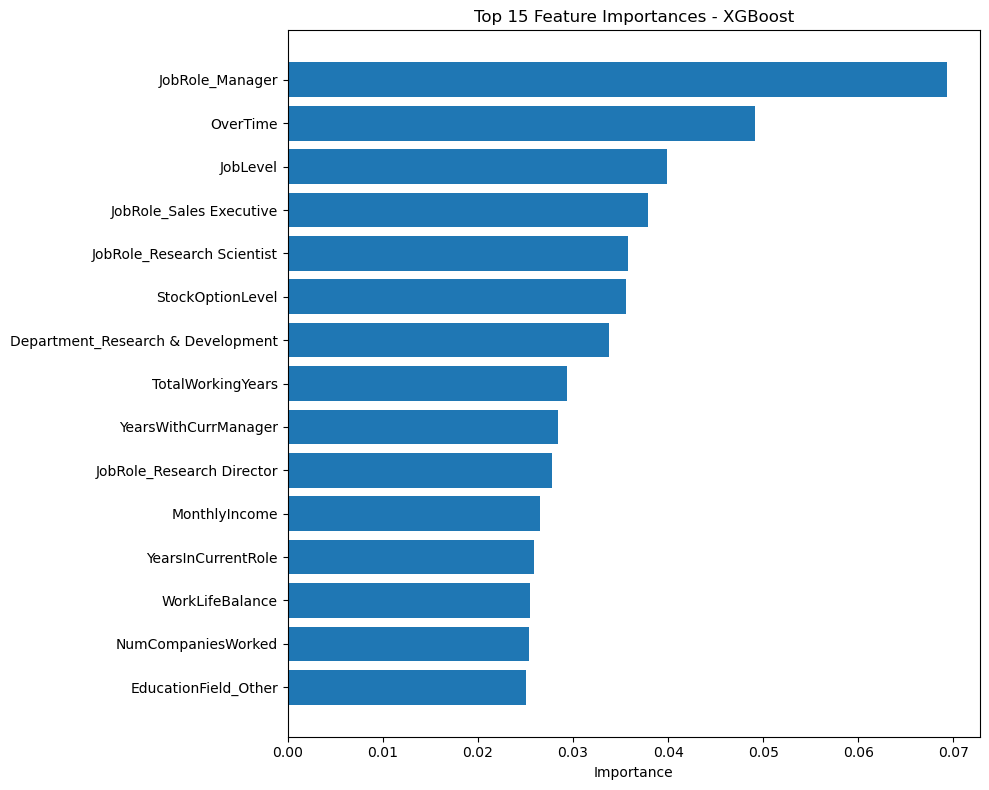

In [34]:
import matplotlib.pyplot as plt

importances = best_xgb.feature_importances_
feat_names = X_train.columns

importance_df = pd.DataFrame({
    'feature': feat_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print(importance_df.head(15))

plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'][:15][::-1], importance_df['importance'][:15][::-1])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - XGBoost')
plt.tight_layout()
plt.show()

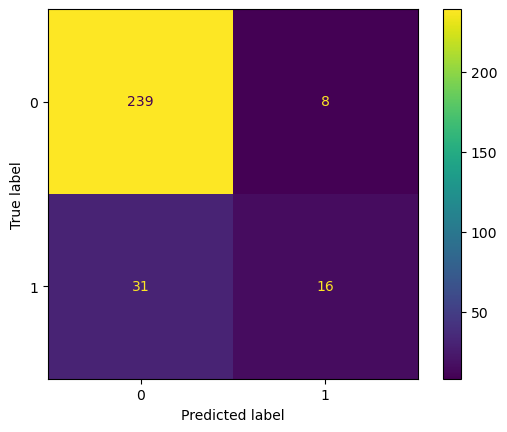

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_xgb, X_test, y_test)
plt.show()

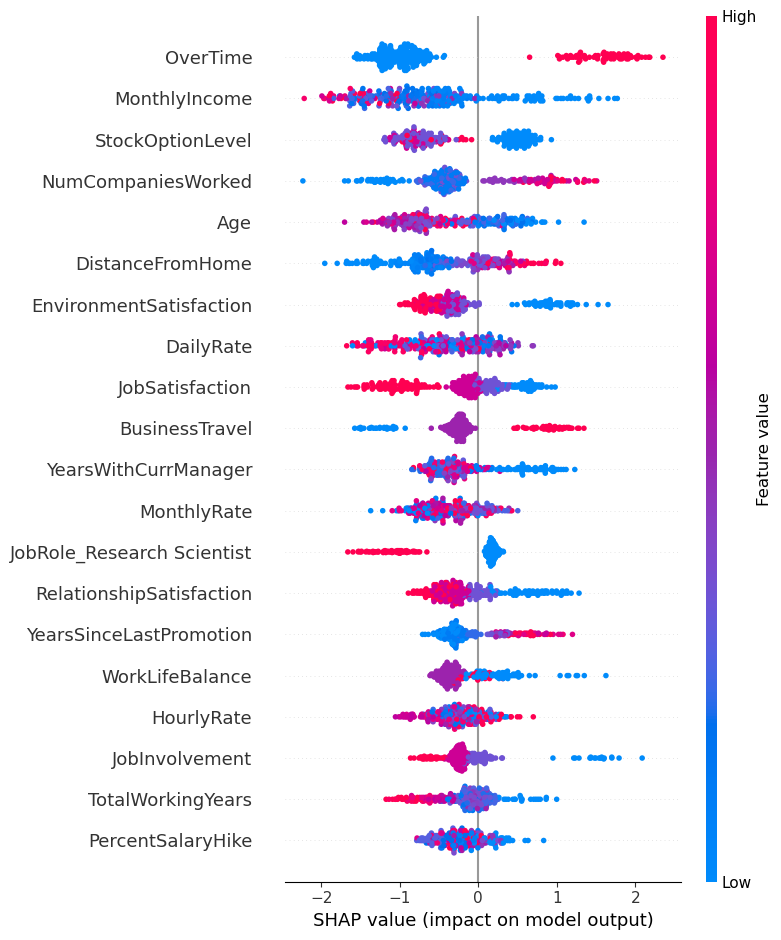

In [42]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [43]:
import joblib

# Save the trained model
joblib.dump(best_xgb, 'xgb_attrition_model.pkl')

# Save the exact column order the model expects
joblib.dump(X_train.columns.tolist(), 'model_columns.pkl')

# Save the tuned decision threshold
joblib.dump(best_threshold, 'decision_threshold.pkl')

# Save the nominal columns used for one-hot encoding (needed to reproduce dummies)
nominal_cols = ['Department', 'EducationField', 'JobRole', 'MaritalStatus']
joblib.dump(nominal_cols, 'nominal_cols.pkl')

print("Saved: model, columns, threshold, nominal_cols")

Saved: model, columns, threshold, nominal_cols
